# Labor Force Dynamics

Suppose you work for a manufacturing organization in the midst of rebalancing your labor force to reflect the evolution of skills and technology in your market. You have identified a target mix of roles and tenure, but your current workforce does not reflect that mix. The primary objective is to reach that target state, but to support organizational planning you need to be able to answer several related questions:

1. What should the size and composition of new hires be in each time period?
2. How long will it take to achieve the target state?
3. How much uncertainty is there in the above estimates?

This class of problem can be characterized as a [Markov Process](https://en.wikipedia.org/wiki/Markov_chain), insofar as it involves understanding transitions between states. This notebook describes how to analyze such a system.

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from enum import Enum
import networkx as nx
from dataclasses import dataclass
from typing import List, Tuple, Dict, Any

# Workforce States and Transitions

In your scheme, you have two role types: $A$ and $B$. You only hire entry level folks (i.e. $A_1$ or $B_1$) or senior folks (i.e. $A_{SR}$ or $B_{SR}$). Entry-level hires become senior members of staff after 3 years. With appropriate training and experience, $A$ staff can take $B$ roles and vice versa, but only once they become senior staff. Attrition is possible for all staff (i.e. they can transition from their role to `NOT_IN_WORKFORCE`). 

The graph below reflects these transition dynamics.

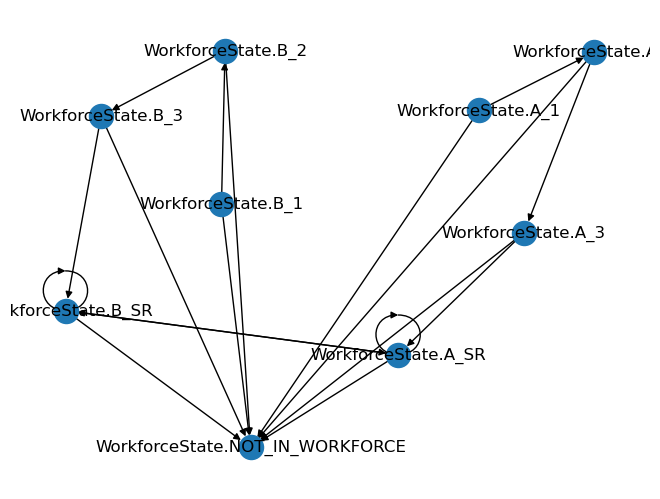

In [ ]:
class WorkforceState(Enum):
    A_1 = 0
    A_2 = 1
    A_3 = 2
    A_SR = 3
    B_1 = 4
    B_2 = 5
    B_3 = 6
    B_SR = 7
    NOT_IN_WORKFORCE = 8

@dataclass
class WorkforceTransition:
    from_state: WorkforceState
    to_state: WorkforceState
    probability: float

class WorkforceModel:

    def __init__(self, transitions: List[WorkforceTransition]) -> None:
        self.transitions = transitions
        self.graph = nx.DiGraph()
        if not self.check_transition_validity(transitions=transitions):
            raise ValueError("Invalid transition probabilities: probabilities from each state must sum to 1.")
        self._load_transitions(transitions=transitions)

    def _load_transitions(self, transitions: List[WorkforceTransition]) -> None:
        for t in transitions:
            self.graph.add_edge(t.from_state, t.to_state, p=t.probability, weight=10 * t.probability)

    @staticmethod
    def check_transition_validity(transitions: List[WorkforceTransition]) -> bool:
        transition_dict: Dict[WorkforceState, float] = {}
        for t in transitions:
            if t.from_state not in transition_dict:
                transition_dict[t.from_state] = 0.0
            transition_dict[t.from_state] += t.probability
        check_dict: Dict[WorkforceState, bool] = {
            state: not np.isclose(total, 1.0) for state, total in transition_dict.items()
        }
        for state, invalid in check_dict.items():
            if invalid == True:
                print(f"Total transition probability from state {state} is {transition_dict[state]}, which is not equal to 1.")
        if any(check_dict.values()):
            return False
        return True
    
    def get_transition_matrix(self) -> xr.DataArray:
        states: List[WorkforceState] = list(WorkforceState)
        n_states: int = len(states)
        matrix: np.ndarray = np.zeros((n_states, n_states))
        for t in self.transitions:
            from_idx: int = states.index(t.from_state)
            to_idx: int = states.index(t.to_state)
            matrix[from_idx, to_idx] = t.probability
        da: xr.DataArray = xr.DataArray(
            data=matrix,
            dims=["from_state", "to_state"],
            coords={"from_state": states, "to_state": states},
        )
        return da
    
    # Needs to be corrected, but the idea is there (copilot is getting really good at this)
    def get_population_matrix(self, initial_population: Dict[WorkforceState, int], n_periods: int) -> xr.DataArray:
        states: List[WorkforceState] = list(WorkforceState)
        n_states: int = len(states)
        population_matrix: np.ndarray = np.zeros((n_periods, n_states))
        for state, population in initial_population.items():
            state_idx: int = states.index(state)
            population_matrix[0, state_idx] = population
        transition_matrix: xr.DataArray = self.get_transition_matrix()
        for t in range(1, n_periods):
            for to_state in states:
                to_idx: int = states.index(to_state)
                total_population: float = 0.0
                for from_state in states:
                    from_idx: int = states.index(from_state)
                    p: float = transition_matrix.sel(from_state=from_state, to_state=to_state).item()
                    total_population += population_matrix[t-1, from_idx] * p
                population_matrix[t, to_idx] = total_population
        da: xr.DataArray = xr.DataArray(
            data=population_matrix,
            dims=["time", "state"],
            coords={"time": np.arange(n_periods), "state": states},
        )
        return da
    

transitions: List[WorkforceTransition] = [
    # WorkforceTransition(WorkforceState.NOT_IN_WORKFORCE, WorkforceState.A_1, 0.25),
    # WorkforceTransition(WorkforceState.NOT_IN_WORKFORCE, WorkforceState.B_1, 0.25),
    # WorkforceTransition(WorkforceState.NOT_IN_WORKFORCE, WorkforceState.A_SR, 0.25),
    # WorkforceTransition(WorkforceState.NOT_IN_WORKFORCE, WorkforceState.B_SR, 0.25),
    WorkforceTransition(WorkforceState.A_1, WorkforceState.A_2, 0.7),
    WorkforceTransition(WorkforceState.A_1, WorkforceState.NOT_IN_WORKFORCE, 0.3),
    WorkforceTransition(WorkforceState.A_2, WorkforceState.A_3, 0.8),
    WorkforceTransition(WorkforceState.A_2, WorkforceState.NOT_IN_WORKFORCE, 0.2),
    WorkforceTransition(WorkforceState.A_3, WorkforceState.A_SR, 0.9),
    WorkforceTransition(WorkforceState.A_3, WorkforceState.NOT_IN_WORKFORCE, 0.1),
    WorkforceTransition(WorkforceState.B_1, WorkforceState.B_2, 0.7),
    WorkforceTransition(WorkforceState.B_1, WorkforceState.NOT_IN_WORKFORCE, 0.3),
    WorkforceTransition(WorkforceState.B_2, WorkforceState.B_3, 0.8),
    WorkforceTransition(WorkforceState.B_2, WorkforceState.NOT_IN_WORKFORCE, 0.2),
    WorkforceTransition(WorkforceState.B_3, WorkforceState.B_SR, 0.9),
    WorkforceTransition(WorkforceState.B_3, WorkforceState.NOT_IN_WORKFORCE, 0.1),
    WorkforceTransition(WorkforceState.A_SR, WorkforceState.A_SR, 0.8),
    WorkforceTransition(WorkforceState.A_SR, WorkforceState.NOT_IN_WORKFORCE, 0.1),
    WorkforceTransition(WorkforceState.A_SR, WorkforceState.B_SR, 0.1),
    WorkforceTransition(WorkforceState.B_SR, WorkforceState.B_SR, 0.8),
    WorkforceTransition(WorkforceState.B_SR, WorkforceState.NOT_IN_WORKFORCE, 0.1),
    WorkforceTransition(WorkforceState.B_SR, WorkforceState.A_SR, 0.1),
]

wf: WorkforceModel = WorkforceModel(transitions=transitions)
nx.draw(wf.graph, with_labels=True)

In [11]:
WorkforceState.__members__.values()

dict_values([<WorkforceState.A_1: 0>, <WorkforceState.A_2: 1>, <WorkforceState.A_3: 2>, <WorkforceState.A_SR: 3>, <WorkforceState.B_1: 4>, <WorkforceState.B_2: 5>, <WorkforceState.B_3: 6>, <WorkforceState.B_SR: 7>, <WorkforceState.NOT_IN_WORKFORCE: 8>])